<a href="https://colab.research.google.com/github/lakithav/ml-internship-journey/blob/main/Feature_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regression Problem

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_regression
X,y = make_regression(n_samples=50,n_features=5)

In [3]:
X

array([[ 1.01739352e+00,  5.82538965e-01, -2.57210812e-01,
         5.62045773e-01,  1.49605566e+00],
       [-5.73625291e-01,  2.27018045e-01, -2.22096071e+00,
         5.18293249e-01, -1.06335986e+00],
       [ 8.03129042e-01,  2.13947580e-01, -6.04479257e-01,
        -5.93579868e-01, -5.86548114e-02],
       [-5.50535224e-05, -1.28096785e+00, -3.62307682e-01,
         7.52651977e-01,  5.15776748e-01],
       [ 7.85640601e-01,  4.53200610e-01,  1.05374398e+00,
         1.14269638e+00,  6.79287773e-01],
       [ 3.41275080e-01, -1.03993251e+00, -5.65885085e-01,
         1.13480377e-02,  1.37735662e+00],
       [ 5.27124138e-02,  1.49029391e+00, -1.12049822e-01,
         1.30550128e-01, -1.67240717e+00],
       [ 2.48952221e-01, -6.21047774e-01, -1.31013469e+00,
        -1.20651687e+00,  7.62937592e-02],
       [ 2.10584349e-01,  9.72051147e-01, -1.03999254e-01,
         9.69508748e-01,  1.12618224e+00],
       [ 1.86494190e+00,  7.60584497e-01, -7.57974334e-01,
         1.57854272e+00

In [4]:
X=pd.DataFrame(X)
X.head()

,0,1,2,3,4
0,1.017394,0.582539,-0.257211,0.562046,1.496056
1,-0.573625,0.227018,-2.220961,0.518293,-1.063360
2,0.803129,0.213948,-0.604479,-0.593580,-0.058655
3,-0.000055,-1.280968,-0.362308,0.752652,0.515777
4,0.785641,0.453201,1.053744,1.142696,0.679288


In [6]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SelectKBest

In [9]:
fs = SelectKBest(score_func=mutual_info_regression,k=3)

In [10]:
fs.fit(X,y)

SelectKBest(k=3, score_func=<function mutual_info_regression at 0x78f7a61f8540>)

In [11]:
fs.scores_

array([0.        , 0.06340293, 0.14898564, 0.16582253, 0.        ])

In [12]:
mi_score = pd. Series(fs.scores_,index=X.columns)
mi_score

,0
0,0.000000
1,0.063403
2,0.148986
3,0.165823
4,0.000000


<Axes: >

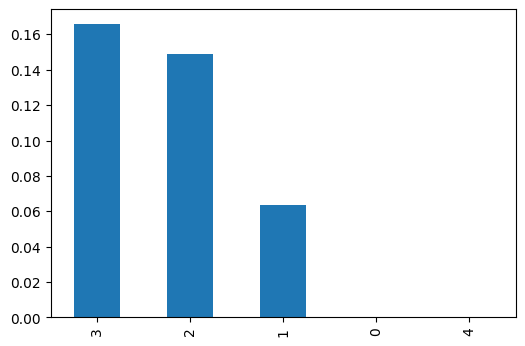

In [13]:
mi_score.sort_values(ascending=False).plot.bar(figsize=(6,4))

In [14]:
X_selected = fs.fit_transform(X,y)
X_selected = pd.DataFrame(X_selected)
X_selected.head()


,0,1,2
0,0.582539,-0.257211,0.562046
1,0.227018,-2.220961,0.518293
2,0.213948,-0.604479,-0.593580
3,-1.280968,-0.362308,0.752652
4,0.453201,1.053744,1.142696


Classification Problem

In [15]:
from sklearn.datasets import make_classification

In [17]:
from sklearn.feature_selection import mutual_info_classif

In [18]:
X,y = make_classification(n_samples = 50, n_features=5,n_informative=2)
X = pd.DataFrame(X)
X.head()

,0,1,2,3,4
0,0.309358,-1.006584,-1.459827,1.896256,1.213991
1,0.310360,0.594883,-0.155208,-1.098456,-0.827146
2,0.402942,-0.071796,0.100305,0.130793,0.108618
3,0.712216,0.609955,0.713930,-1.145341,-0.754027
4,-0.115293,-0.659017,-0.835213,1.238859,0.807796


In [19]:
fs = SelectKBest(score_func=mutual_info_classif,k=3)
fs.fit(X,y)

SelectKBest(k=3, score_func=<function mutual_info_classif at 0x78f7a61f8680>)

<Axes: >

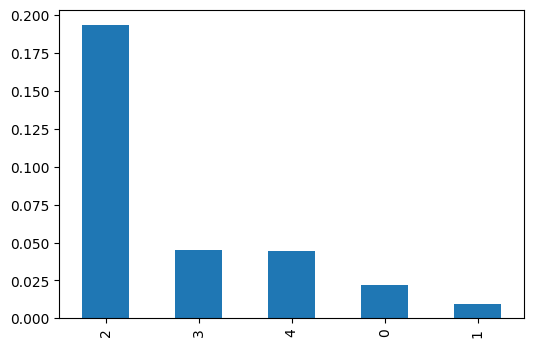

In [20]:
mi_score = pd. Series(fs.scores_,index=X.columns)
mi_score.sort_values(ascending=False).plot.bar(figsize=(6,4))

In [21]:
X_selected = fs.fit_transform(X,y)
X_selected = pd.DataFrame(X_selected)
X_selected.head()

,0,1,2
0,-1.459827,1.896256,1.213991
1,-0.155208,-1.098456,-0.827146
2,0.100305,0.130793,0.108618
3,0.713930,-1.145341,-0.754027
4,-0.835213,1.238859,0.807796
